# 🧑‍🏫 Aula 2 — Classificação Supervisionada Multivariada + Hyperparameter Tuning

**UC:** Machine Learning | **Data:** 22/04/2026 | **Duração:** 3 horas

---

## 🎯 Objetivos desta Aula

Nesta aula vamos **aprofundar** a classificação de qualidade de tecidos que iniciamos na Aula 1. Vamos:

1. 📊 **Análise Multivariada** — entender como as features se relacionam entre si (correlação, pair plots, VIF)
2. 🤖 **Múltiplos Classificadores** — treinar SVM, KNN, XGBoost e LightGBM, cada um registrado no MLflow
3. 🎛️ **Hyperparameter Tuning** — buscar automaticamente os melhores hiperparâmetros com GridSearchCV e RandomizedSearchCV
4. ⏹️ **Early Stopping** — parar o treinamento automaticamente quando o modelo não melhora mais
5. 📈 **Comparação Final** — analisar qual modelo é melhor para cada cenário (velocidade vs acurácia vs interpretabilidade)

### Recapitulando a Aula 1:

Na aula anterior, construímos um **pipeline completo de ML**:
- Limpamos o dataset (nulos, duplicatas, ruído)
- Fizemos encoding das variáveis categóricas
- Treinamos um RandomForest
- Registramos tudo no MLflow

Hoje, vamos **partir do dataset já limpo** da Aula 1 e focar nos novos conteúdos.

---

📦 **Dataset:** [Textile Fabric Quality Classification](https://www.kaggle.com/datasets/devendrakushwah08/textile-fabric-quality-classification-dataset) — dataset limpo da Aula 1

## 1️⃣ Configuração do Ambiente e Importação de Bibliotecas

Vamos usar as mesmas bibliotecas da Aula 1, mais algumas novas:

| Biblioteca | Para que serve | Novidade? |
|---|---|---|
| `pandas` / `numpy` | Manipulação de dados | — |
| `matplotlib` / `seaborn` | Visualizações | — |
| `scikit-learn` | ML (SVM, KNN, GridSearchCV, etc.) | ✅ Novos classificadores e tuning |
| `xgboost` | Gradient Boosting otimizado | ✅ Novo |
| `lightgbm` | Gradient Boosting ultra-rápido | ✅ Novo |
| `statsmodels` | VIF (Variance Inflation Factor) | ✅ Novo |
| `mlflow` | Tracking de experimentos | — |
| `joblib` | Salvar/carregar modelos | — |

In [1]:
# ============================================================
# INSTALAÇÃO DAS DEPENDÊNCIAS
# ============================================================
# Instala todas as bibliotecas necessárias para esta aula.
# xgboost e lightgbm são algoritmos de Gradient Boosting de alto desempenho.
# statsmodels é usado para calcular o VIF (Variance Inflation Factor).

!pip install -q pandas numpy matplotlib seaborn scikit-learn mlflow xgboost lightgbm statsmodels joblib

In [2]:
# ============================================================
# IMPORTAÇÃO DAS BIBLIOTECAS
# ============================================================

# --- Manipulação de Dados ---
import pandas as pd                  # Tabelas (DataFrames)
import numpy as np                   # Operações matemáticas

# --- Visualização ---
import matplotlib.pyplot as plt      # Gráficos
import seaborn as sns                # Gráficos estatísticos

# --- Machine Learning (scikit-learn) ---
from sklearn.model_selection import train_test_split       # Divisão treino/teste
from sklearn.preprocessing import StandardScaler           # Padronização
from sklearn.preprocessing import LabelEncoder             # Encoding de labels
from sklearn.metrics import (                              # Métricas de avaliação
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# *** NOVOS CLASSIFICADORES ***
from sklearn.svm import SVC                                # Support Vector Machine
from sklearn.neighbors import KNeighborsClassifier         # K-Nearest Neighbors

# *** HYPERPARAMETER TUNING ***
from sklearn.model_selection import GridSearchCV            # Busca exaustiva
from sklearn.model_selection import RandomizedSearchCV      # Busca aleatória
from sklearn.model_selection import cross_val_score         # Validação cruzada

# --- Gradient Boosting ---
import xgboost as xgb                # XGBoost — Gradient Boosting otimizado
import lightgbm as lgb               # LightGBM — Gradient Boosting ultra-rápido

# --- Análise Estatística ---
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF

# --- Tracking de Experimentos ---
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# --- Utilitários ---
import joblib
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Configuração visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ Todas as bibliotecas foram importadas com sucesso!")

✅ Todas as bibliotecas foram importadas com sucesso!


## 2️⃣ Configuração do MLflow

Vamos criar um **novo experimento** no MLflow para a Aula 2. Assim, os runs desta aula ficam separados dos da Aula 1, mas no mesmo banco de dados — permitindo comparações entre aulas no futuro.

```
📁 MLflow Database (mlflow.db)
├── 🧪 aula01_qualidade_textil     ← Aula 1 (RandomForest, DecisionTree)
└── 🧪 aula02_classificacao_tuning  ← Aula 2 (SVM, KNN, XGBoost, LightGBM + Tuning)
```

In [3]:
# ============================================================
# CONFIGURAÇÃO DO MLFLOW
# ============================================================
# Mesmo banco de dados da Aula 1, mas experimento novo.
# Isso permite comparar resultados entre aulas no futuro.

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("aula02_classificacao_tuning")

print("✅ MLflow configurado!")
print(f"   📁 Tracking URI: {mlflow.get_tracking_uri()}")
print(f"   🧪 Experimento: aula02_classificacao_tuning")

2026/04/22 20:07:45 INFO mlflow.tracking.fluent: Experiment with name 'aula02_classificacao_tuning' does not exist. Creating a new experiment.


✅ MLflow configurado!
   📁 Tracking URI: sqlite:///../mlflow.db
   🧪 Experimento: aula02_classificacao_tuning


## 3️⃣ Carregamento do Dataset Limpo (Aula 1)

Na Aula 1, limpamos o dataset original (tratamos nulos, duplicatas, removemos colunas de ruído e fizemos encoding). O resultado foi salvo em `dataset_limpo.csv`.

Agora vamos **carregar esse dataset pronto** para focar nos novos conteúdos desta aula.

> 💡 **Na prática industrial**, é comum ter pipelines de dados já prontos. Você raramente começa do zero em cada análise — reutiliza artefatos de etapas anteriores.

In [4]:
# ============================================================
# CARREGAMENTO DO DATASET LIMPO DA AULA 1
# ============================================================
# Tenta carregar os artefatos da Aula 1.
# Se não encontrar, baixa e processa o dataset novamente.

AULA01_DIR = os.path.join("..", "Aula_01")
MODELOS_AULA01_DIR = os.path.join("..", "modelos", "aula01")

# Caminhos dos artefatos da Aula 1
dataset_path = os.path.join(AULA01_DIR, "dataset_limpo.csv")
encoders_path = os.path.join(MODELOS_AULA01_DIR, "encoders_qualidade_textil_v1.joblib")
features_path = os.path.join(MODELOS_AULA01_DIR, "features_qualidade_textil_v1.joblib")

# Carrega o dataset limpo
if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print(f"✅ Dataset limpo carregado de: {dataset_path}")
else:
    # Fallback: baixa o dataset e faz a limpeza básica
    print("⚠️  Dataset limpo não encontrado. Baixando e processando...")
    import kagglehub
    raw_path = kagglehub.dataset_download(
        "devendrakushwah08/textile-fabric-quality-classification-dataset"
    )
    csv_files = [f for f in os.listdir(raw_path) if f.endswith('.csv')]
    df = pd.read_csv(os.path.join(raw_path, csv_files[0]))

    # Limpeza básica (mesmos passos da Aula 1)
    df = df.drop_duplicates()
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    keywords_ruido = ['id', 'batch', 'roll', 'warehouse', 'operator', 'note',
                      'inspector', 'timestamp', 'date', 'shift']
    colunas_remover = [col for col in df.columns
                       if any(kw in col.lower() for kw in keywords_ruido)]
    df = df.drop(columns=colunas_remover, errors='ignore')
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = LabelEncoder().fit_transform(df[col])
    print("✅ Dataset processado com sucesso!")

# Carrega a lista de features e encoders da Aula 1
if os.path.exists(features_path):
    feature_names = joblib.load(features_path)
    print(f"✅ Feature names carregados ({len(feature_names)} features)")
else:
    feature_names = [col for col in df.columns if col != 'fabric_quality']
    print(f"⚠️  Features inferidas do dataset ({len(feature_names)} features)")

if os.path.exists(encoders_path):
    encoders = joblib.load(encoders_path)
    le_target = encoders.get('fabric_quality', LabelEncoder().fit(df['fabric_quality'].unique()))
    print(f"✅ Encoders carregados")
else:
    le_target = LabelEncoder().fit(['High', 'Low', 'Medium'])
    print(f"⚠️  Encoder do target recriado")

# --- Identificar coluna alvo ---
TARGET = 'fabric_quality'

print(f"\n📊 Dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"🎯 Target: '{TARGET}'")
print(f"📐 Features: {feature_names[:5]}... ({len(feature_names)} total)")
df.head()

⚠️  Dataset limpo não encontrado. Baixando e processando...
✅ Dataset processado com sucesso!
✅ Feature names carregados (15 features)
✅ Encoders carregados

📊 Dataset: 25,000 linhas × 16 colunas
🎯 Target: 'fabric_quality'
📐 Features: ['thread_count', 'gsm', 'tensile_strength', 'shrinkage_percent', 'color_fastness']... (15 total)


,thread_count,gsm,tensile_strength,shrinkage_percent,color_fastness,fabric_thickness,defect_count,elongation_percent,moisture_absorption,fabric_type,weave_type,finish_type,production_method,inspection_time_minutes,machine_temperature,fabric_quality
0,166.0,383.0,67.772683,7.744704,1,0.891865,11,31.299228,12.855777,2,2,2,0,45.957289,28.148868,1
1,273.0,107.0,106.508682,1.191272,1,0.872380,4,8.092515,7.224689,2,1,0,0,33.035982,42.033282,0
2,274.0,352.0,97.100410,5.274223,3,1.231906,3,24.134907,12.276679,3,1,1,0,35.768493,35.450923,0
3,213.0,200.0,17.876660,4.001214,1,0.320100,12,18.334479,14.732114,1,2,1,1,38.349274,23.459327,1
4,115.0,348.0,62.746013,2.529863,2,0.903725,14,6.396909,11.692512,0,0,1,1,44.339097,33.873426,1


## 4️⃣ Análise Multivariada

A **análise multivariada** estuda como múltiplas variáveis se relacionam **simultaneamente**. Na Aula 1, vimos a correlação entre pares de features. Agora vamos ir além:

### Técnicas que vamos usar:

| Técnica | O que faz | Por que importa |
|---|---|---|
| **Pair Plot** | Gráfico de dispersão entre **todas** as combinações de features | Visualizar padrões e separações entre classes |
| **VIF** (Variance Inflation Factor) | Mede a **multicolinearidade** entre features | Identificar features redundantes que confundem o modelo |
| **Correlação com a Target** | Mede quanto cada feature se relaciona com a qualidade | Identificar features mais relevantes para a classificação |

### O que é Multicolinearidade?

Quando duas ou mais features são **muito correlacionadas** entre si, dizemos que há multicolinearidade. Exemplo:
- `tensile_strength` e `elongation_percent` podem ser correlacionadas (tecidos mais resistentes tendem a esticar menos)
- Se incluirmos ambas, o modelo pode ficar **confuso** sobre qual usar

O **VIF** quantifica esse problema: VIF > 10 indica multicolinearidade preocupante.

📊 Criando pair plot com 6 features...
   Features: ['thread_count', 'gsm', 'tensile_strength', 'shrinkage_percent', 'fabric_thickness', 'defect_count']


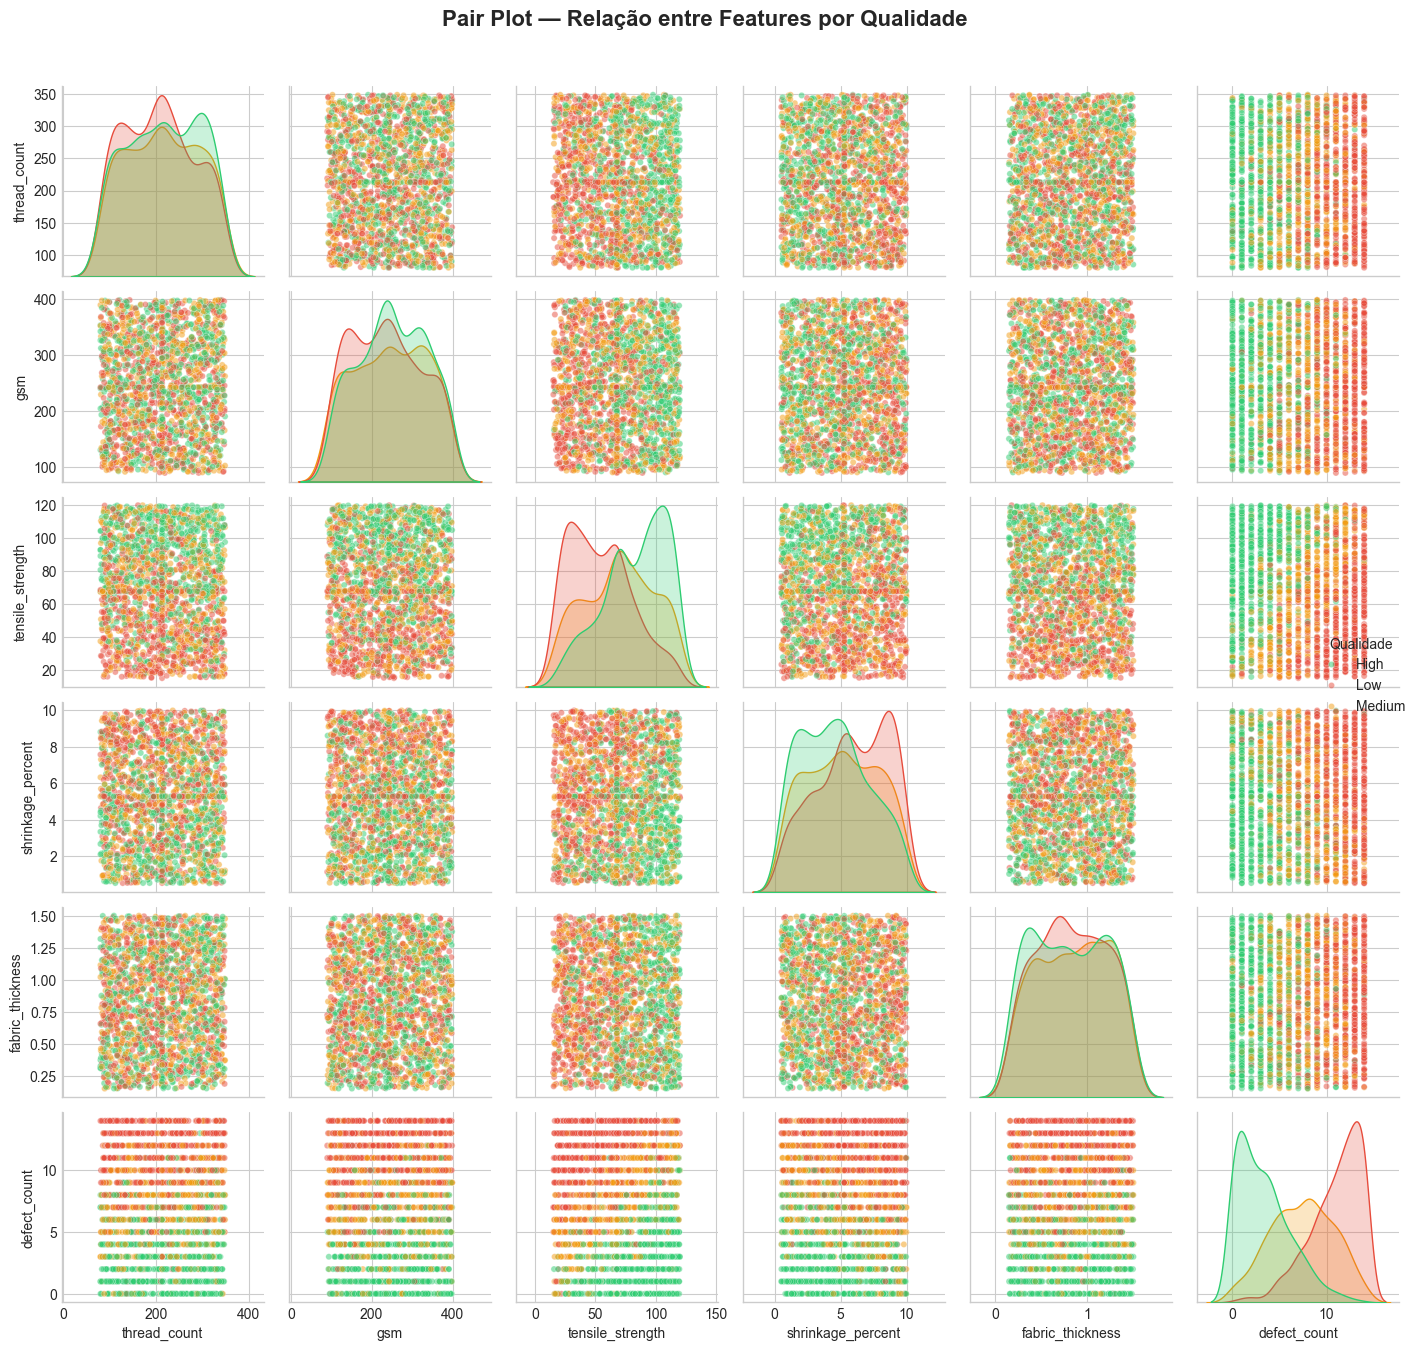


💡 O que observar:
   • Regiões onde as cores (classes) se SEPARAM → feature discriminativa!
   • Regiões onde as cores se MISTURAM → feature pouco útil para classificação
   • Diagonal: distribuição de cada feature por classe (KDE = Kernel Density Estimate)


In [5]:
# ============================================================
# 4.1 — PAIR PLOT (GRÁFICO DE DISPERSÃO MULTIVARIADO)
# ============================================================
# O pair plot mostra TODAS as combinações de features em gráficos de
# dispersão, coloridos pela classe alvo. Isso revela visualmente
# quais features melhor separam as classes.
#
# ⚠️ Com muitas features, o gráfico fica gigante. Vamos selecionar
# as 5 features numéricas mais relevantes para manter legível.

# Seleciona as features numéricas contínuas para o pair plot
# (exclui features que foram originalmente categóricas, pois seus pair plots não são informativos)
features_continuas = ['thread_count', 'gsm', 'tensile_strength', 'shrinkage_percent',
                      'fabric_thickness', 'defect_count', 'elongation_percent',
                      'moisture_absorption', 'inspection_time_minutes', 'machine_temperature']

# Filtra apenas as que existem no dataset
features_pair = [f for f in features_continuas if f in df.columns][:6]

print(f"📊 Criando pair plot com {len(features_pair)} features...")
print(f"   Features: {features_pair}")

# Cria DataFrame com as features selecionadas + target decodificado
# Decodifica o target para nomes legíveis (High, Low, Medium)
try:
    df_pair = df[features_pair].copy()
    df_pair['Qualidade'] = le_target.inverse_transform(df[TARGET].astype(int))
except:
    df_pair = df[features_pair].copy()
    mapa = {0: 'High', 1: 'Low', 2: 'Medium'}
    df_pair['Qualidade'] = df[TARGET].map(mapa)

# Amostra para performance (pair plot com 25K pontos é lento)
df_pair_sample = df_pair.sample(n=min(2000, len(df_pair)), random_state=42)

# Cria o pair plot
g = sns.pairplot(df_pair_sample, hue='Qualidade',
                 palette={'High': '#2ecc71', 'Low': '#e74c3c', 'Medium': '#f39c12'},
                 diag_kind='kde',        # Diagonal: distribuição (KDE)
                 plot_kws={'alpha': 0.5, 's': 20},  # Transparência e tamanho dos pontos
                 height=2.2)

g.figure.suptitle('Pair Plot — Relação entre Features por Qualidade',
                   y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('pair_plot_features.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n💡 O que observar:")
print("   • Regiões onde as cores (classes) se SEPARAM → feature discriminativa!")
print("   • Regiões onde as cores se MISTURAM → feature pouco útil para classificação")
print("   • Diagonal: distribuição de cada feature por classe (KDE = Kernel Density Estimate)")

### 4.2 — VIF (Variance Inflation Factor)

O **VIF** responde à pergunta: *"Essa feature pode ser explicada pelas outras features?"*

$$VIF_i = \frac{1}{1 - R^2_i}$$

Onde $R^2_i$ é o coeficiente de determinação da regressão da feature $i$ contra todas as outras features.

| VIF | Interpretação |
|---|---|
| **1** | Sem multicolinearidade (ideal) |
| **1–5** | Multicolinearidade moderada (aceitável) |
| **5–10** | Multicolinearidade alta (atenção) |
| **> 10** | Multicolinearidade severa (considerar remover a feature) |

### Por que remover features com VIF alto?

- **Instabilidade nos coeficientes:** pequenas mudanças nos dados causam grandes mudanças no modelo
- **Dificuldade de interpretação:** não dá para saber qual feature realmente importa
- **Overfitting:** o modelo aprende padrões redundantes ao invés de padrões reais

> 🏭 **Na indústria:** se `tensile_strength` e `elongation_percent` têm VIF > 10, elas estão medindo quase a mesma coisa. Manter apenas uma simplifica o processo de inspeção sem perder informação.

📊 Variance Inflation Factor (VIF) por Feature:
   machine_temperature            VIF =    15.63  🔴 SEVERA (> 10)
   thread_count                   VIF =     7.96  🟡 ALTA (5-10)
   gsm                            VIF =     7.89  🟡 ALTA (5-10)
   moisture_absorption            VIF =     7.03  🟡 ALTA (5-10)
   tensile_strength               VIF =     5.85  🟡 ALTA (5-10)
   elongation_percent             VIF =     5.65  🟡 ALTA (5-10)
   color_fastness                 VIF =     5.18  🟡 ALTA (5-10)
   fabric_thickness               VIF =     5.16  🟡 ALTA (5-10)
   inspection_time_minutes        VIF =     4.92  🟢 MODERADA (1-5)
   shrinkage_percent              VIF =     4.64  🟢 MODERADA (1-5)
   defect_count                   VIF =     3.50  🟢 MODERADA (1-5)
   fabric_type                    VIF =     2.66  🟢 MODERADA (1-5)
   weave_type                     VIF =     2.57  🟢 MODERADA (1-5)
   finish_type                    VIF =     2.47  🟢 MODERADA (1-5)
   production_method              VIF

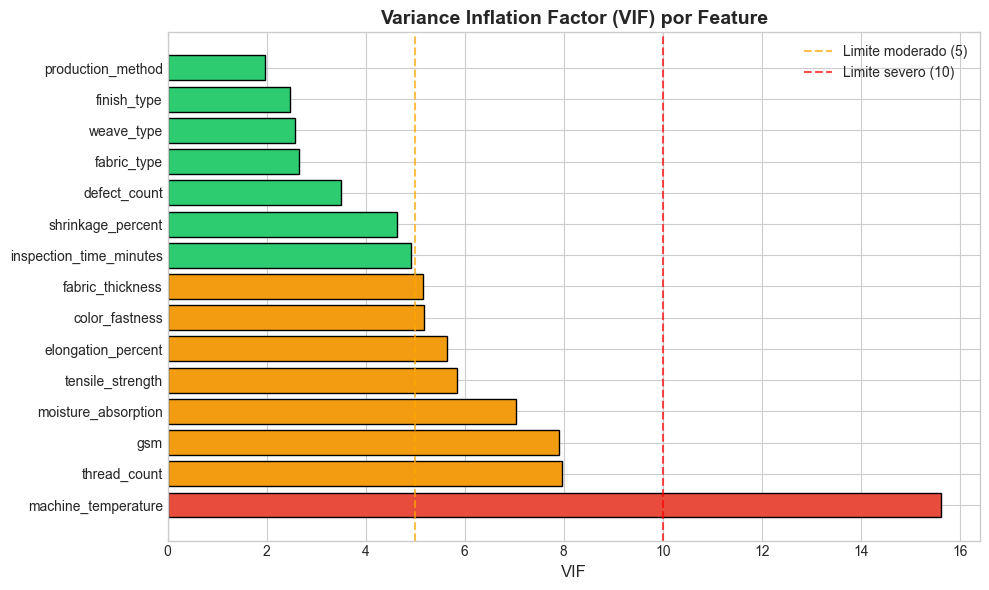


⚠️  1 features com VIF > 10: ['machine_temperature']
   Considerar remover em análises futuras. Nesta aula, vamos mantê-las
   para comparar como diferentes classificadores lidam com multicolinearidade.


In [6]:
# ============================================================
# 4.2 — CÁLCULO DO VIF (VARIANCE INFLATION FACTOR)
# ============================================================
# O VIF mede quanto cada feature é "explicada" pelas demais.
# VIF alto = a feature é redundante (pode ser prevista pelas outras).

# Seleciona apenas features numéricas (exclui target)
X_vif = df[feature_names].copy()

# Calcula VIF para cada feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i)
                    for i in range(X_vif.shape[1])]

# Ordena por VIF (maior primeiro)
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# Classifica o nível de multicolinearidade
def classificar_vif(vif):
    if vif > 10:
        return '🔴 SEVERA (> 10)'
    elif vif > 5:
        return '🟡 ALTA (5-10)'
    elif vif > 1:
        return '🟢 MODERADA (1-5)'
    else:
        return '✅ SEM (= 1)'

vif_data['Classificação'] = vif_data['VIF'].apply(classificar_vif)

print("📊 Variance Inflation Factor (VIF) por Feature:")
print("=" * 65)
for _, row in vif_data.iterrows():
    print(f"   {row['Feature']:30s} VIF = {row['VIF']:8.2f}  {row['Classificação']}")
print("=" * 65)

# Visualização
fig, ax = plt.subplots(figsize=(10, max(5, len(vif_data) * 0.4)))
colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71'
          for v in vif_data['VIF']]
bars = ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors, edgecolor='black')
ax.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='Limite moderado (5)')
ax.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='Limite severo (10)')
ax.set_xlabel('VIF', fontsize=12)
ax.set_title('Variance Inflation Factor (VIF) por Feature', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('vif_features.png', dpi=100, bbox_inches='tight')
plt.show()

# Identifica features com VIF severo
features_vif_alto = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
if features_vif_alto:
    print(f"\n⚠️  {len(features_vif_alto)} features com VIF > 10: {features_vif_alto}")
    print("   Considerar remover em análises futuras. Nesta aula, vamos mantê-las")
    print("   para comparar como diferentes classificadores lidam com multicolinearidade.")
else:
    print("\n✅ Nenhuma feature com VIF > 10. Bom sinal!")

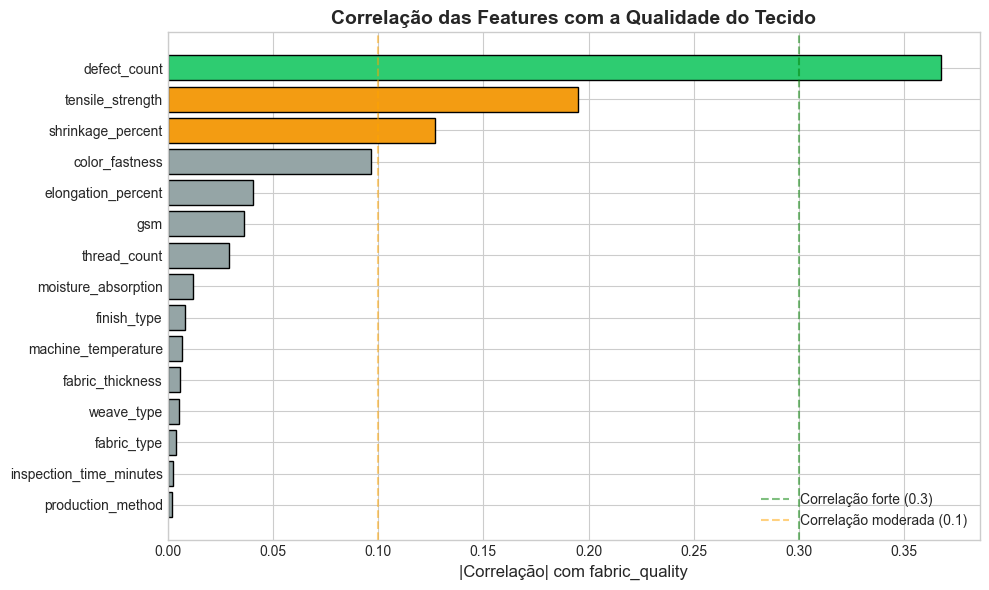

💡 Features com maior correlação (absoluta) com a qualidade:
   🔍 elongation_percent: 0.0403
   🔍 color_fastness: 0.0968
   🔍 shrinkage_percent: 0.1272
   🔍 tensile_strength: 0.1952
   🔍 defect_count: 0.3676


In [7]:
# ============================================================
# 4.3 — CORRELAÇÃO DAS FEATURES COM A VARIÁVEL ALVO
# ============================================================
# Quais features mais se correlacionam com a qualidade do tecido?
# Isso nos ajuda a entender o que IMPORTA para a classificação.

# Calcula correlação de cada feature com o target
corr_target = df[feature_names + [TARGET]].corr()[TARGET].drop(TARGET)
corr_target = corr_target.abs().sort_values(ascending=True)  # Valor absoluto

fig, ax = plt.subplots(figsize=(10, max(5, len(corr_target) * 0.4)))

colors = ['#2ecc71' if v > 0.3 else '#f39c12' if v > 0.1 else '#95a5a6'
          for v in corr_target.values]
bars = ax.barh(corr_target.index, corr_target.values, color=colors, edgecolor='black')
ax.axvline(x=0.3, color='green', linestyle='--', alpha=0.5, label='Correlação forte (0.3)')
ax.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='Correlação moderada (0.1)')
ax.set_xlabel('|Correlação| com fabric_quality', fontsize=12)
ax.set_title('Correlação das Features com a Qualidade do Tecido', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('correlacao_com_target.png', dpi=100, bbox_inches='tight')
plt.show()

print("💡 Features com maior correlação (absoluta) com a qualidade:")
for feat, corr in corr_target.tail(5).items():
    print(f"   🔍 {feat}: {corr:.4f}")

## 5️⃣ Preparação dos Dados para Classificação

Agora vamos preparar os dados para treinar **múltiplos classificadores**. O processo é o mesmo da Aula 1:

1. Separar features (X) e target (y)
2. Dividir em treino (80%) e teste (20%)
3. Padronizar com StandardScaler

> ⚠️ **Importante:** Usamos o mesmo `random_state=42` da Aula 1 para manter a comparabilidade dos resultados.

In [8]:
# ============================================================
# SEPARAÇÃO, DIVISÃO E PADRONIZAÇÃO DOS DADOS
# ============================================================

# 1. Separar features (X) e target (y)
X = df[feature_names]
y = df[TARGET]

print(f"📦 Features (X): {X.shape}")
print(f"🎯 Target  (y): {y.shape} → classes: {sorted(y.unique())}")

# 2. Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\n📊 Treino: {X_train.shape[0]:,} amostras | Teste: {X_test.shape[0]:,} amostras")

# 3. Padronizar com StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform no treino
X_test_scaled = scaler.transform(X_test)          # apenas transform no teste

print("✅ Dados prontos para treinamento!")

# Nomes das classes para exibição
try:
    nomes_classes = le_target.classes_
except:
    nomes_classes = np.array(['High', 'Low', 'Medium'])
print(f"   Classes: {list(nomes_classes)}")

📦 Features (X): (25000, 15)
🎯 Target  (y): (25000,) → classes: [np.int64(0), np.int64(1), np.int64(2)]

📊 Treino: 20,000 amostras | Teste: 5,000 amostras
✅ Dados prontos para treinamento!
   Classes: ['High', 'Low', 'Medium']


## 6️⃣ Treinamento de Múltiplos Classificadores

Agora vamos treinar **4 classificadores diferentes**, cada um com sua estratégia de decisão:

| Classificador | Como Funciona | Pontos Fortes | Pontos Fracos |
|---|---|---|---|
| **SVM** (Support Vector Machine) | Encontra o **hiperplano** que melhor separa as classes | Eficiente com muitas features, bom com dados de alta dimensão | Lento com datasets grandes, sensível à escala |
| **KNN** (K-Nearest Neighbors) | Classifica pela **maioria dos K vizinhos** mais próximos | Simples, sem fase de treino, bom para decisões locais | Lento na predição, sensível a features irrelevantes |
| **XGBoost** | **Gradient Boosting** — árvores corrigem erros umas das outras sequencialmente | Muito preciso, lida com dados complexos, paralelizável | Pode overfitar, muitos hiperparâmetros para ajustar |
| **LightGBM** | Gradient Boosting **otimizado** — crescimento folha a folha | Ultra-rápido, baixo consumo de memória | Pode overfitar com datasets pequenos |

> 🏭 **Na indústria:** cada classificador tem seus trade-offs. O SVM é bom para dados de alta dimensão (muitos sensores), o KNN para decisões locais (peças similares), e XGBoost/LightGBM para máxima acurácia quando velocidade de treino não é crítica.

In [9]:
# ============================================================
# FUNÇÃO AUXILIAR: TREINAR, AVALIAR E REGISTRAR NO MLFLOW
# ============================================================
# Para não repetir código, criamos uma função que:
# 1. Treina o modelo
# 2. Faz predições
# 3. Calcula métricas
# 4. Registra tudo no MLflow
# 5. Plota a matriz de confusão
#
# Esta função será usada em TODOS os classificadores abaixo.

def treinar_e_avaliar(modelo, nome_run, params_dict, X_tr, y_tr, X_te, y_te,
                       nomes_classes, tempo_treino=None):
    '''
    Treina um modelo, avalia no conjunto de teste e registra no MLflow.

    Parâmetros:
    -----------
    modelo        : estimador sklearn/xgboost/lightgbm já instanciado
    nome_run      : nome do run no MLflow (ex: "SVM_v1")
    params_dict   : dicionário de hiperparâmetros (para logging)
    X_tr, y_tr    : dados de treino (já escalados)
    X_te, y_te    : dados de teste (já escalados)
    nomes_classes : array com nomes das classes
    tempo_treino  : tempo de treinamento em segundos (opcional)

    Retorna:
    --------
    dict com métricas do modelo
    '''
    with mlflow.start_run(run_name=nome_run):
        # --- Registra parâmetros ---
        for param, valor in params_dict.items():
            mlflow.log_param(param, valor)
        mlflow.log_param("algoritmo", nome_run.split("_")[0])

        # --- Treina o modelo (se não foi pré-treinado) ---
        if tempo_treino is None:
            inicio = time.time()
            modelo.fit(X_tr, y_tr)
            tempo_treino = time.time() - inicio

        # --- Faz predições ---
        y_pred = modelo.predict(X_te)

        # --- Calcula métricas ---
        acc = accuracy_score(y_te, y_pred)
        f1 = f1_score(y_te, y_pred, average='macro')

        # --- Registra métricas no MLflow ---
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_macro", f1)
        mlflow.log_metric("tempo_treino_seg", round(tempo_treino, 3))

        # --- Registra o modelo ---
        mlflow.sklearn.log_model(modelo, f"modelo_{nome_run.lower()}")

        # --- Matriz de Confusão ---
        fig, ax = plt.subplots(figsize=(7, 5))
        cm = confusion_matrix(y_te, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=nomes_classes, yticklabels=nomes_classes,
                    square=True, linewidths=1, linecolor='white', ax=ax)
        ax.set_xlabel('Predição', fontsize=12, fontweight='bold')
        ax.set_ylabel('Real', fontsize=12, fontweight='bold')
        ax.set_title(f'Matriz de Confusão — {nome_run}', fontsize=13, fontweight='bold')
        plt.tight_layout()

        cm_filename = f'cm_{nome_run.lower()}.png'
        plt.savefig(cm_filename, dpi=100, bbox_inches='tight')
        mlflow.log_artifact(cm_filename, "graficos")
        plt.show()

        # --- Imprime resultados ---
        print(f"📊 {nome_run}:")
        print(f"   Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
        print(f"   F1-Score:  {f1:.4f}")
        print(f"   Tempo:     {tempo_treino:.3f}s")
        print(f"   Run ID:    {mlflow.active_run().info.run_id}")

    return {
        'modelo': nome_run,
        'accuracy': acc,
        'f1_macro': f1,
        'tempo_treino': tempo_treino,
        'y_pred': y_pred
    }

# Lista para armazenar resultados de todos os modelos
resultados_todos = []
print("✅ Função auxiliar criada! Pronta para treinar os classificadores.")

✅ Função auxiliar criada! Pronta para treinar os classificadores.


### 6.1 — SVM (Support Vector Machine)

O SVM procura o **hiperplano** (uma "fronteira de decisão") que melhor separa as classes, maximizando a **margem** entre os pontos mais próximos de cada classe (chamados **vetores de suporte**).

#### Conceitos-chave:
- **Kernel:** função que transforma os dados para um espaço de maior dimensão onde eles se tornam linearmente separáveis
  - `linear`: fronteira reta  
  - `rbf` (Radial Basis Function): fronteira curva (mais flexível)
  - `poly`: fronteira polinomial
- **C (Regularização):** controla o trade-off entre margem e erros
  - C alto → margem estreita, menos erros no treino (risco de overfitting)
  - C baixo → margem larga, mais erros no treino (mais generalizável)

> 🏭 **Na inspeção de tecidos:** imagine que os pontos no gráfico são amostras de tecido (cada eixo é uma propriedade). O SVM traça a "linha" que melhor separa qualidade baixa de alta.

2026/04/22 20:20:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 20:20:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


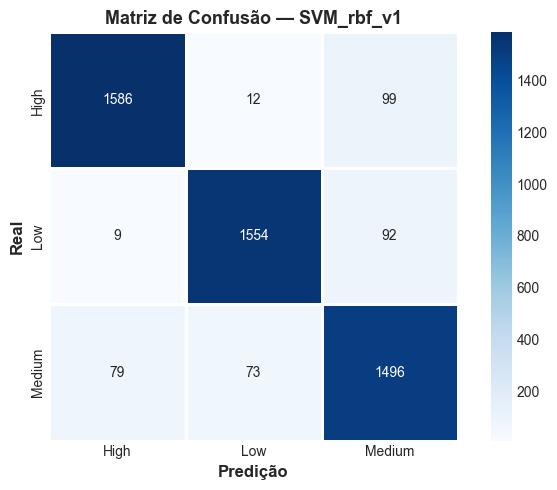

📊 SVM_rbf_v1:
   Accuracy:  0.9272 (92.72%)
   F1-Score:  0.9272
   Tempo:     3.742s
   Run ID:    7f67914b350749c4bf0dee6917aff04b


In [10]:
# ============================================================
# 6.1 — TREINAMENTO DO SVM
# ============================================================
# SVM com kernel RBF (o mais usado para dados não-lineares)

params_svm = {
    "kernel": "rbf",       # Kernel RBF (fronteira curva)
    "C": 1.0,              # Regularização padrão
    "gamma": "scale",      # Gamma automático baseado na variância dos dados
    "random_state": 42
}

modelo_svm = SVC(**params_svm)

resultado_svm = treinar_e_avaliar(
    modelo=modelo_svm,
    nome_run="SVM_rbf_v1",
    params_dict=params_svm,
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_te=X_test_scaled,
    y_te=y_test,
    nomes_classes=nomes_classes
)

resultados_todos.append(resultado_svm)

### 6.2 — KNN (K-Nearest Neighbors)

O KNN é um dos algoritmos mais **intuitivos** de ML. Para classificar um novo ponto, ele:

1. Calcula a **distância** entre o novo ponto e TODOS os pontos de treino
2. Seleciona os **K vizinhos mais próximos**
3. A classe do novo ponto = **voto da maioria** dos K vizinhos

#### Hiperparâmetro-chave: K
- **K pequeno** (ex: 3) → decisões locais, pode ser sensível a ruído
- **K grande** (ex: 21) → decisões mais suaves, pode perder detalhes

> 🏭 **Analogia:** para classificar um novo tecido, o KNN "olha" para os K tecidos mais parecidos já inspecionados e segue a maioria. É como perguntar a opinião dos inspetores mais experientes com amostras similares.

> ⚠️ **Importante:** O KNN é muito sensível à escala dos dados. Por isso a padronização (StandardScaler) é ESSENCIAL.

2026/04/22 20:24:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 20:24:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


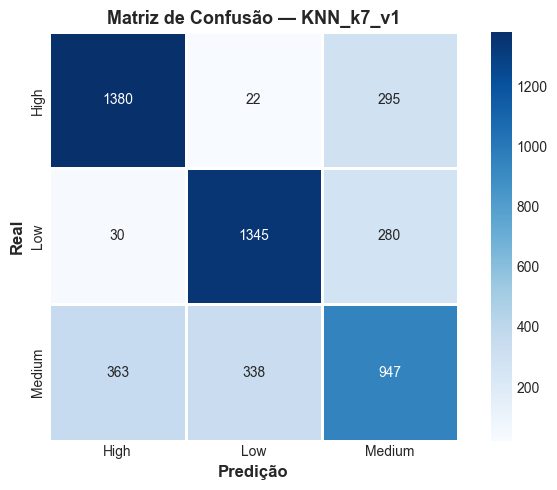

📊 KNN_k7_v1:
   Accuracy:  0.7344 (73.44%)
   F1-Score:  0.7312
   Tempo:     0.042s
   Run ID:    3bcdcdb94a804384ba99971f3aa9d7f1


In [11]:
# ============================================================
# 6.2 — TREINAMENTO DO KNN
# ============================================================

params_knn = {
    "n_neighbors": 7,       # 7 vizinhos (número ímpar evita empate)
    "metric": "minkowski",   # Distância de Minkowski (padrão = Euclidiana com p=2)
    "p": 2,                  # p=2 → distância Euclidiana
    "n_jobs": -1             # Usa todos os cores (paraleliza o cálculo de distâncias)
}

modelo_knn = KNeighborsClassifier(**params_knn)

resultado_knn = treinar_e_avaliar(
    modelo=modelo_knn,
    nome_run="KNN_k7_v1",
    params_dict=params_knn,
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_te=X_test_scaled,
    y_te=y_test,
    nomes_classes=nomes_classes
)

resultados_todos.append(resultado_knn)

### 6.3 — XGBoost (eXtreme Gradient Boosting)

O XGBoost é um dos algoritmos **mais populares** em competições de ML e na indústria. Ele pertence à família **Gradient Boosting**:

#### Como funciona o Gradient Boosting:
1. Treina uma árvore de decisão simples (fraca)
2. Calcula os **erros** (resíduos) dessa árvore
3. Treina uma **nova árvore para corrigir os erros** da anterior
4. Repete até ter `n_estimators` árvores
5. O resultado final = **soma das predições** de todas as árvores

Cada árvore sozinha é fraca, mas juntas são muito poderosas!

#### Hiperparâmetros importantes:
| Parâmetro | O que faz |
|---|---|
| `n_estimators` | Número de árvores (rounds de boosting) |
| `max_depth` | Profundidade máxima de cada árvore |
| `learning_rate` | Quanto cada árvore contribui (taxa de aprendizado) |
| `subsample` | Fração dos dados usada por árvore (regularização) |

> 🏭 **Na prática:** XGBoost é imbatível em dados tabulares como os da indústria (sensores, métricas, inspeções).

2026/04/22 20:27:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 20:27:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


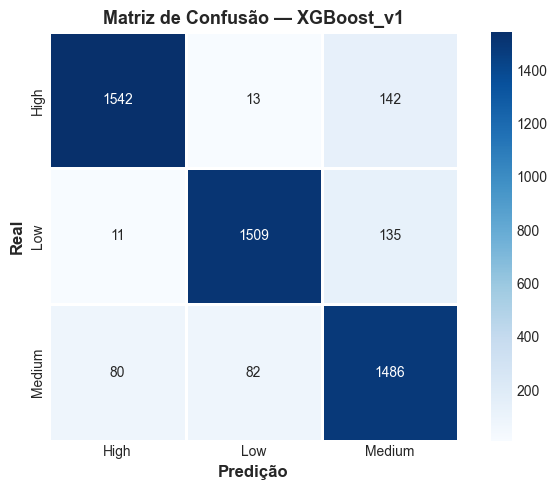

📊 XGBoost_v1:
   Accuracy:  0.9074 (90.74%)
   F1-Score:  0.9078
   Tempo:     2.097s
   Run ID:    b37a4dfb415d401cbd5b59f3800c8b3b


In [12]:
# ============================================================
# 6.3 — TREINAMENTO DO XGBOOST
# ============================================================

params_xgb = {
    "n_estimators": 100,       # 100 árvores
    "max_depth": 6,            # Árvores de profundidade 6
    "learning_rate": 0.1,      # Taxa de aprendizado
    "subsample": 0.8,          # 80% dos dados por árvore (regularização)
    "colsample_bytree": 0.8,   # 80% das features por árvore
    "random_state": 42,
    "use_label_encoder": False,
    "eval_metric": "mlogloss"  # Métrica de avaliação interna
}

modelo_xgb = xgb.XGBClassifier(**params_xgb)

resultado_xgb = treinar_e_avaliar(
    modelo=modelo_xgb,
    nome_run="XGBoost_v1",
    params_dict=params_xgb,
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_te=X_test_scaled,
    y_te=y_test,
    nomes_classes=nomes_classes
)

resultados_todos.append(resultado_xgb)

### 6.4 — LightGBM (Light Gradient Boosting Machine)

O LightGBM é uma variante do Gradient Boosting desenvolvida pela **Microsoft** que é **significativamente mais rápida** que o XGBoost.

#### Diferença principal: estratégia de crescimento das árvores

| Algoritmo | Estratégia | Analogia |
|---|---|---|
| **XGBoost** | Crescimento **por nível** (level-wise) | Poda todos os galhos da mesma altura |
| **LightGBM** | Crescimento **por folha** (leaf-wise) | Cresce o galho que dá mais ganho |

O crescimento por folha é mais eficiente: foca no caminho que mais reduz o erro, ignorando o resto.

#### Outras otimizações do LightGBM:
- **Gradient-based One-Side Sampling (GOSS):** dá mais atenção aos exemplos difíceis
- **Exclusive Feature Bundling (EFB):** combina features mutuamente exclusivas para reduzir dimensão

> ⚠️ **Cuidado:** O LightGBM pode **overfitar** mais facilmente que o XGBoost em datasets pequenos, justamente por ser mais "agressivo".

2026/04/22 20:29:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 20:29:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


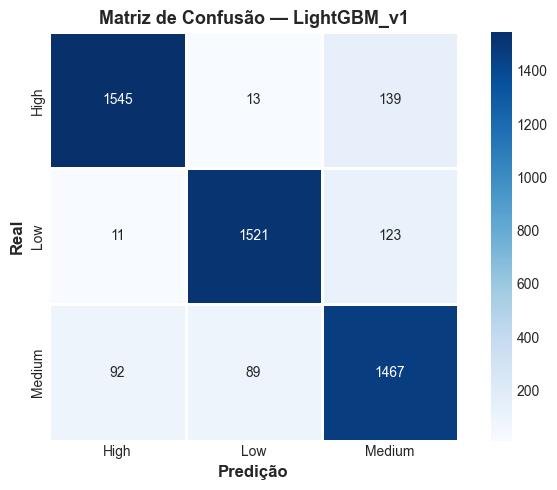

📊 LightGBM_v1:
   Accuracy:  0.9066 (90.66%)
   F1-Score:  0.9069
   Tempo:     3.377s
   Run ID:    bce74895429f49c78cbe1b5a06eadd8d


In [13]:
# ============================================================
# 6.4 — TREINAMENTO DO LIGHTGBM
# ============================================================

params_lgbm = {
    "n_estimators": 100,        # 100 árvores
    "max_depth": 6,             # Profundidade máxima
    "learning_rate": 0.1,       # Taxa de aprendizado
    "subsample": 0.8,           # 80% dos dados por iteração
    "colsample_bytree": 0.8,    # 80% das features por árvore
    "random_state": 42,
    "verbose": -1               # Silencia outputs internos do LightGBM
}

modelo_lgbm = lgb.LGBMClassifier(**params_lgbm)

resultado_lgbm = treinar_e_avaliar(
    modelo=modelo_lgbm,
    nome_run="LightGBM_v1",
    params_dict=params_lgbm,
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_te=X_test_scaled,
    y_te=y_test,
    nomes_classes=nomes_classes
)

resultados_todos.append(resultado_lgbm)

In [ ]:
# ============================================================
# COMPARAÇÃO PARCIAL: 4 CLASSIFICADORES BASE
# ============================================================
# Antes de fazer o tuning, vamos ver como os classificadores se saem
# com suas configurações padrão (sem otimização de hiperparâmetros).

df_resultados = pd.DataFrame(resultados_todos)[['modelo', 'accuracy', 'f1_macro', 'tempo_treino']]
df_resultados = df_resultados.sort_values('f1_macro', ascending=False)

print("=" * 70)
print("📊 COMPARAÇÃO DOS CLASSIFICADORES BASE (sem tuning)")
print("=" * 70)
print(df_resultados.to_string(index=False))
print("=" * 70)

melhor = df_resultados.iloc[0]
print(f"\n🏆 Melhor classificador (F1): {melhor['modelo']} com F1 = {melhor['f1_macro']:.4f}")

📊 COMPARAÇÃO DOS CLASSIFICADORES BASE (sem tuning)
     modelo  accuracy  f1_macro  tempo_treino
 SVM_rbf_v1    0.9272  0.927217      2.493082
 XGBoost_v1    0.9078  0.908225      0.436564
LightGBM_v1    0.9066  0.906863      2.002116
  KNN_k7_v1    0.7344  0.731154      0.036525

🏆 Melhor classificador (F1): SVM_rbf_v1 com F1 = 0.9272


## 7️⃣ Hyperparameter Tuning

Até agora, usamos hiperparâmetros "padrão" (escolhidos manualmente). Mas como saber se são os **melhores**?

O **Hyperparameter Tuning** é o processo de buscar automaticamente a **melhor combinação de hiperparâmetros** para um modelo.

### Duas técnicas principais:

| Técnica | Como funciona | Prós | Contras |
|---|---|---|---|
| **GridSearchCV** | Testa **TODAS** as combinações possíveis de um grid | Garante encontrar o melhor no grid | Lento (cresce exponencialmente) |
| **RandomizedSearchCV** | Testa um número **fixo de combinações aleatórias** | Rápido, explora mais o espaço | Pode perder o ótimo |

### Como funciona a Validação Cruzada (CV)?

```
Dataset de Treino (80%)
├── Fold 1: [Treino: 75%] [Validação: 25%] → Score₁
├── Fold 2: [Treino: 75%] [Validação: 25%] → Score₂
├── Fold 3: [Treino: 75%] [Validação: 25%] → Score₃
├── Fold 4: [Treino: 75%] [Validação: 25%] → Score₄
└── Fold 5: [Treino: 75%] [Validação: 25%] → Score₅
                                              ─────────
                                              Score final = Média
```

> ⚠️ **Importante:** O tuning é feito APENAS nos dados de treino. O conjunto de teste permanece intocado até a avaliação final.

### 7.1 — GridSearchCV com SVM

O GridSearchCV vai testar **TODAS** as combinações de hiperparâmetros que definirmos. Com o SVM, vamos testar:

- **C:** [0.1, 1, 10] → 3 valores de regularização
- **kernel:** ['rbf', 'linear'] → 2 tipos de fronteira
- **gamma:** ['scale', 'auto'] → 2 estratégias de cálculo

Total de combinações: 3 × 2 × 2 = **12 combinações** × 5 folds = **60 modelos treinados**

> 💡 Imagine o grid como uma planilha 3D onde cada célula é uma combinação de hiperparâmetros. O GridSearch treina um modelo em CADA célula.

🔍 GridSearchCV — SVM
   Combinações a testar: 12
   Com 5-fold CV: 60 modelos serão treinados
   Grid: {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': ['scale', 'auto']}

✅ GridSearchCV concluído em 158.3s

🏆 Melhores hiperparâmetros encontrados:
   C: 10
   gamma: scale
   kernel: linear

📊 Melhor F1-Score (CV): 0.9538


2026/04/22 21:13:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 21:13:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


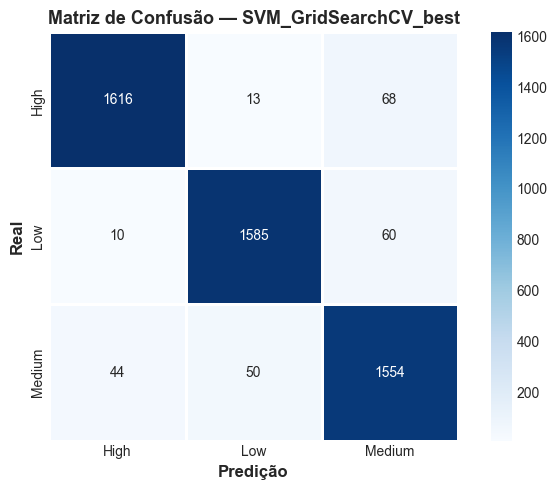

📊 SVM_GridSearchCV_best:
   Accuracy:  0.9510 (95.10%)
   F1-Score:  0.9510
   Tempo:     158.350s
   Run ID:    cf950578473949bd8acbee043be7df7c


In [14]:
# ============================================================
# 7.1 — GRIDSEARCHCV COM SVM
# ============================================================
# Definimos um GRID de hiperparâmetros e o GridSearchCV testa TODOS.

# Define o grid de hiperparâmetros para o SVM
param_grid_svm = {
    'C': [0.1, 1, 10],            # Força da regularização
    'kernel': ['rbf', 'linear'],    # Tipo de fronteira de decisão
    'gamma': ['scale', 'auto']      # Cálculo do coeficiente do kernel
}

# Conta total de combinações
n_combinacoes = 1
for v in param_grid_svm.values():
    n_combinacoes *= len(v)
print(f"🔍 GridSearchCV — SVM")
print(f"   Combinações a testar: {n_combinacoes}")
print(f"   Com 5-fold CV: {n_combinacoes * 5} modelos serão treinados")
print(f"   Grid: {param_grid_svm}\n")

# Executa o GridSearchCV
inicio = time.time()
grid_search_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid_svm,
    cv=5,                  # 5-fold cross-validation
    scoring='f1_macro',    # Métrica para comparação
    n_jobs=-1,             # Paraleliza nos cores do CPU
    verbose=0,             # Sem output verbose
    return_train_score=True  # Também salva score do treino
)

grid_search_svm.fit(X_train_scaled, y_train)
tempo_grid = time.time() - inicio

# Mostra os melhores parâmetros encontrados
print(f"✅ GridSearchCV concluído em {tempo_grid:.1f}s")
print(f"\n🏆 Melhores hiperparâmetros encontrados:")
for param, valor in grid_search_svm.best_params_.items():
    print(f"   {param}: {valor}")
print(f"\n📊 Melhor F1-Score (CV): {grid_search_svm.best_score_:.4f}")

# --- Registra no MLflow ---
resultado_grid_svm = treinar_e_avaliar(
    modelo=grid_search_svm.best_estimator_,
    nome_run="SVM_GridSearchCV_best",
    params_dict={**grid_search_svm.best_params_, "tuning": "GridSearchCV", "cv_folds": 5},
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_te=X_test_scaled,
    y_te=y_test,
    nomes_classes=nomes_classes,
    tempo_treino=tempo_grid
)

resultados_todos.append(resultado_grid_svm)

In [17]:
# ============================================================
# DETALHAMENTO DOS RESULTADOS DO GRIDSEARCHCV
# ============================================================
# Vamos ver o desempenho de TODAS as combinações testadas.

# Converte resultados em DataFrame para análise
resultados_grid = pd.DataFrame(grid_search_svm.cv_results_)

# Seleciona colunas relevantes
cols_mostrar = ['param_C', 'param_kernel', 'param_gamma',
                'mean_test_score', 'std_test_score', 'rank_test_score',
                'mean_train_score']
resultados_grid_resumo = resultados_grid[cols_mostrar].sort_values('rank_test_score')

print("📋 Resultados de TODAS as combinações do GridSearchCV:")
print("=" * 90)
print(resultados_grid_resumo.to_string(index=False))
print("=" * 90)
print(f"\n💡 Observe:")
print(f"   • A combinação #1 é a melhor (rank_test_score = 1)")
print(f"   • Se mean_train_score >> mean_test_score → possível overfitting")
print(f"   • std_test_score alto → resultado instável entre os folds")

📋 Resultados de TODAS as combinações do GridSearchCV:
 param_C param_kernel param_gamma  mean_test_score  std_test_score  rank_test_score  mean_train_score
    10.0       linear        auto         0.953771        0.001746                1          0.953947
    10.0       linear       scale         0.953771        0.001746                1          0.953947
     1.0       linear        auto         0.953472        0.001844                3          0.953822
     1.0       linear       scale         0.953472        0.001844                3          0.953822
     0.1       linear       scale         0.952794        0.002354                5          0.953716
     0.1       linear        auto         0.952794        0.002354                5          0.953716
     0.1          rbf        auto         0.927007        0.002032                7          0.938086
     0.1          rbf       scale         0.926958        0.002016                8          0.938086
     1.0          rbf       

### 7.2 — RandomizedSearchCV com XGBoost

O RandomizedSearchCV é mais **eficiente** que o GridSearchCV porque:
- Em vez de testar TODAS as combinações, sorteia um número fixo de combinações
- Consegue explorar faixas contínuas de valores (não apenas valores discretos)
- Com `n_iter=20`, treinamos apenas 20 combinações × 5 folds = **100 modelos** (vs centenas no Grid)

#### Distribuições de hiperparâmetros:

Para o XGBoost, vamos definir **faixas** (distribuições) ao invés de listas:
- `n_estimators`: entre 50 e 300
- `max_depth`: entre 3 e 10
- `learning_rate`: entre 0.01 e 0.3
- `subsample`: entre 0.6 e 1.0

🔍 RandomizedSearchCV — XGBoost
   Combinações a testar: 20 (aleatórias)
   Com 5-fold CV: 100 modelos serão treinados
   Distribuições:
      n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000240F1A38440>
      max_depth: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000240F1A079D0>
      learning_rate: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000240F1A38590>
      subsample: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000240F1A802D0>
      colsample_bytree: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000240F1A80550>

✅ RandomizedSearchCV concluído em 38.0s

🏆 Melhores hiperparâmetros encontrados:
   colsample_bytree: 0.6063
   learning_rate: 0.1328
   max_depth: 3
   n_estimators: 285
   subsample: 0.7174

📊 Melhor F1-Score (CV): 0.9219


2026/04/22 21:14:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 21:14:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


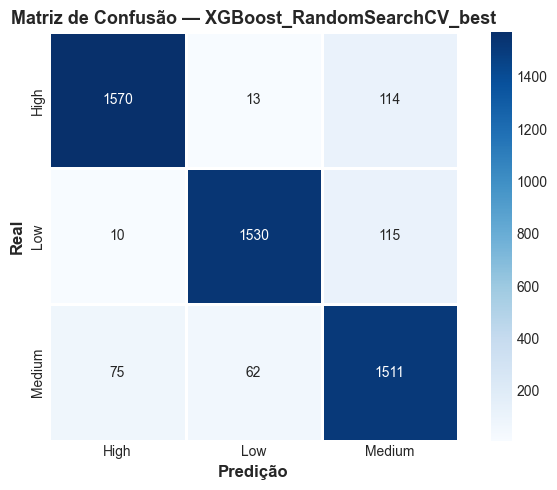

📊 XGBoost_RandomSearchCV_best:
   Accuracy:  0.9222 (92.22%)
   F1-Score:  0.9225
   Tempo:     38.022s
   Run ID:    b90b90ffbd31451ea52d74cea7dbe36b


In [18]:
# ============================================================
# 7.2 — RANDOMIZEDSEARCHCV COM XGBOOST
# ============================================================
# Define distribuições (faixas) ao invés de listas fixas.
# O RandomizedSearchCV sorteia combinações dessas faixas.

from scipy.stats import randint, uniform

# Define distribuições de hiperparâmetros
param_distributions_xgb = {
    'n_estimators': randint(50, 301),          # Inteiro entre 50 e 300
    'max_depth': randint(3, 11),               # Inteiro entre 3 e 10
    'learning_rate': uniform(0.01, 0.29),      # Float entre 0.01 e 0.30
    'subsample': uniform(0.6, 0.4),            # Float entre 0.6 e 1.0
    'colsample_bytree': uniform(0.6, 0.4),     # Float entre 0.6 e 1.0
}

print(f"🔍 RandomizedSearchCV — XGBoost")
print(f"   Combinações a testar: 20 (aleatórias)")
print(f"   Com 5-fold CV: 100 modelos serão treinados")
print(f"   Distribuições:")
for param, dist in param_distributions_xgb.items():
    print(f"      {param}: {dist}")

# Executa o RandomizedSearchCV
inicio = time.time()
random_search_xgb = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss',
        verbosity=0
    ),
    param_distributions=param_distributions_xgb,
    n_iter=20,             # Apenas 20 combinações (vs todas no Grid)
    cv=5,                  # 5-fold cross-validation
    scoring='f1_macro',    # Métrica para comparação
    n_jobs=-1,
    random_state=42,
    verbose=0,
    return_train_score=True
)

random_search_xgb.fit(X_train_scaled, y_train)
tempo_random = time.time() - inicio

# Mostra os melhores parâmetros encontrados
print(f"\n✅ RandomizedSearchCV concluído em {tempo_random:.1f}s")
print(f"\n🏆 Melhores hiperparâmetros encontrados:")
for param, valor in random_search_xgb.best_params_.items():
    if isinstance(valor, float):
        print(f"   {param}: {valor:.4f}")
    else:
        print(f"   {param}: {valor}")
print(f"\n📊 Melhor F1-Score (CV): {random_search_xgb.best_score_:.4f}")

# --- Registra no MLflow ---
best_params_log = {k: round(v, 4) if isinstance(v, float) else v
                   for k, v in random_search_xgb.best_params_.items()}
resultado_random_xgb = treinar_e_avaliar(
    modelo=random_search_xgb.best_estimator_,
    nome_run="XGBoost_RandomSearchCV_best",
    params_dict={**best_params_log, "tuning": "RandomizedSearchCV", "n_iter": 20, "cv_folds": 5},
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_te=X_test_scaled,
    y_te=y_test,
    nomes_classes=nomes_classes,
    tempo_treino=tempo_random
)

resultados_todos.append(resultado_random_xgb)

## 8️⃣ Early Stopping

O **Early Stopping** é uma técnica para **evitar overfitting** em algoritmos iterativos (como XGBoost e LightGBM). A ideia é simples:

1. Treinamos o modelo e monitoramos o desempenho no conjunto de **validação** a cada iteração
2. Se o desempenho **parar de melhorar** por N iterações consecutivas, paramos o treino

```
Iteração  1: loss_treino = 0.80, loss_validação = 0.82
Iteração 10: loss_treino = 0.40, loss_validação = 0.45   ← Melhorando ✅
Iteração 20: loss_treino = 0.20, loss_validação = 0.35   ← Melhorando ✅
Iteração 30: loss_treino = 0.10, loss_validação = 0.36   ← Parou de melhorar ⚠️
Iteração 40: loss_treino = 0.05, loss_validação = 0.38   ← PIORANDO no validação! ❌
           → PARE AQUI! (voltamos para a iteração 20)
```

### Por que usar Early Stopping?

- **Evita overfitting:** o modelo para antes de "decorar" os dados de treino
- **Economiza tempo:** não treina iterações desnecessárias
- **Automático:** não precisa adivinhar o número ideal de `n_estimators`

> 🏭 **Analogia:** É como ajustar uma máquina de tear — você vai refinando até o tecido ficar bom, mas para antes de estragar.

📊 Divisão para Early Stopping:
   Treino real:  17,000 amostras
   Validação:    3,000 amostras
   Teste final:  5,000 amostras

⏹️ Early Stopping atuou!
   Máximo permitido:   500 rounds
   Rounds efetivos:    495 rounds
   Economia:           5 rounds (1%)


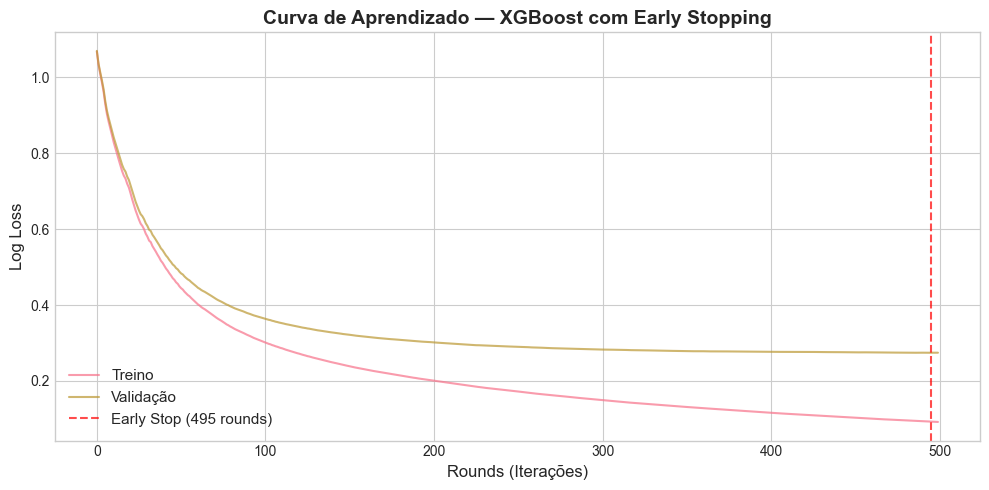

2026/04/22 21:15:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 21:15:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


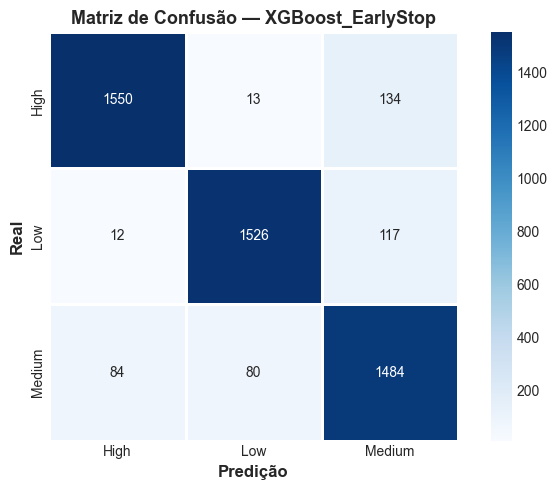

📊 XGBoost_EarlyStop:
   Accuracy:  0.9120 (91.20%)
   F1-Score:  0.9123
   Tempo:     2.188s
   Run ID:    24641b12ee5c46d08d8ebb3a306caad8


In [19]:
# ============================================================
# 8.1 — XGBOOST COM EARLY STOPPING
# ============================================================
# Separamos uma parte do treino como "validação" para monitorar o early stopping.
# O XGBoost usa o eval_set para avaliar a cada round.

# Divide treino em treino_real (85%) e validação (15%) para early stopping
X_tr_es, X_val_es, y_tr_es, y_val_es = train_test_split(
    X_train_scaled, y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print(f"📊 Divisão para Early Stopping:")
print(f"   Treino real:  {X_tr_es.shape[0]:,} amostras")
print(f"   Validação:    {X_val_es.shape[0]:,} amostras")
print(f"   Teste final:  {X_test_scaled.shape[0]:,} amostras")

# XGBoost com MUITAS iterações (500), mas early stopping vai parar antes
params_xgb_es = {
    "n_estimators": 500,          # Máximo de 500 árvores
    "max_depth": 6,
    "learning_rate": 0.05,        # Learning rate menor = treino mais suave
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "use_label_encoder": False,
    "eval_metric": "mlogloss",
    "early_stopping_rounds": 30,  # Para se não melhorar em 30 rounds
    "verbosity": 0
}

modelo_xgb_es = xgb.XGBClassifier(**params_xgb_es)

# Treina com eval_set para monitorar o early stopping
inicio = time.time()
modelo_xgb_es.fit(
    X_tr_es, y_tr_es,
    eval_set=[(X_tr_es, y_tr_es), (X_val_es, y_val_es)],
    verbose=False
)
tempo_es = time.time() - inicio

# Quantas iterações o modelo efetivamente usou?
n_rounds_usados = modelo_xgb_es.best_iteration + 1
print(f"\n⏹️ Early Stopping atuou!")
print(f"   Máximo permitido:   500 rounds")
print(f"   Rounds efetivos:    {n_rounds_usados} rounds")
print(f"   Economia:           {500 - n_rounds_usados} rounds ({(500-n_rounds_usados)/500*100:.0f}%)")

# --- Curva de learning do XGBoost ---
resultados_treino = modelo_xgb_es.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(resultados_treino['validation_0']['mlogloss'], label='Treino', alpha=0.7)
ax.plot(resultados_treino['validation_1']['mlogloss'], label='Validação', alpha=0.7)
ax.axvline(x=n_rounds_usados, color='red', linestyle='--', alpha=0.7,
           label=f'Early Stop ({n_rounds_usados} rounds)')
ax.set_xlabel('Rounds (Iterações)', fontsize=12)
ax.set_ylabel('Log Loss', fontsize=12)
ax.set_title('Curva de Aprendizado — XGBoost com Early Stopping', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('xgb_early_stopping.png', dpi=100, bbox_inches='tight')
plt.show()

# Registra no MLflow
params_log_es = {k: v for k, v in params_xgb_es.items() if k != 'verbosity'}
params_log_es["rounds_efetivos"] = n_rounds_usados

resultado_xgb_es = treinar_e_avaliar(
    modelo=modelo_xgb_es,
    nome_run="XGBoost_EarlyStop",
    params_dict=params_log_es,
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_te=X_test_scaled,
    y_te=y_test,
    nomes_classes=nomes_classes,
    tempo_treino=tempo_es
)

resultados_todos.append(resultado_xgb_es)

⏹️ Early Stopping — LightGBM:
   Máximo permitido:   500 rounds
   Rounds efetivos:    489 rounds
   Economia:           11 rounds (2%)


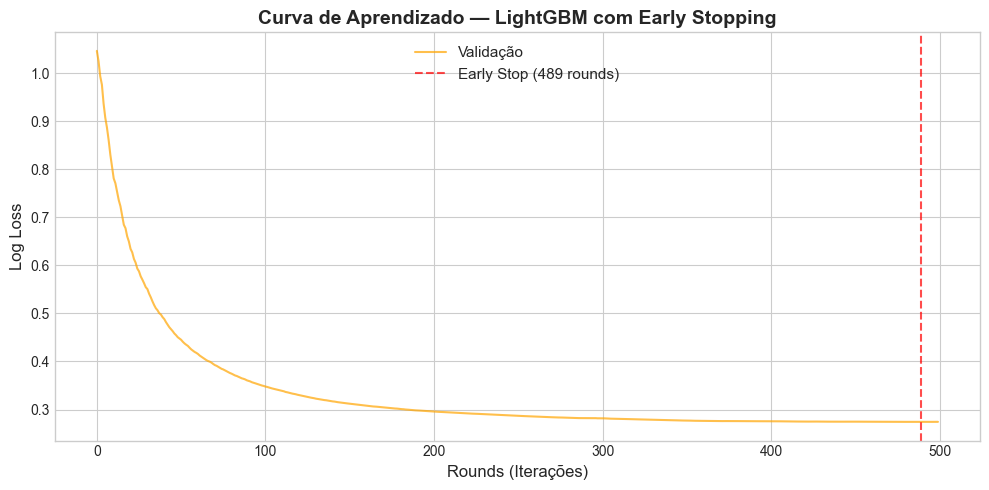

2026/04/22 21:15:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/22 21:15:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


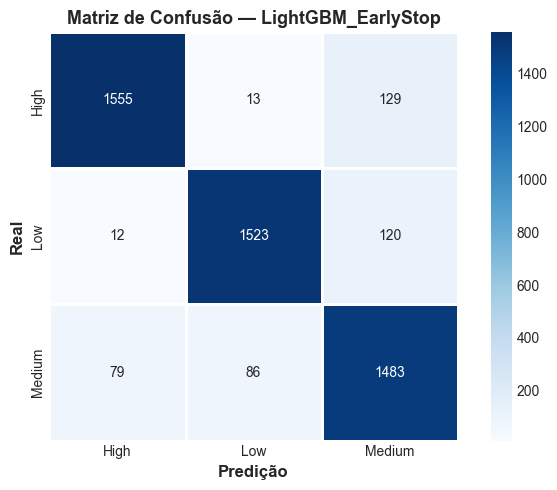

📊 LightGBM_EarlyStop:
   Accuracy:  0.9122 (91.22%)
   F1-Score:  0.9124
   Tempo:     1.058s
   Run ID:    bdcfa90e217b4adbb2550076e87488c4


In [20]:
# ============================================================
# 8.2 — LIGHTGBM COM EARLY STOPPING
# ============================================================
# O LightGBM também suporta early stopping via callbacks.

params_lgbm_es = {
    "n_estimators": 500,          # Máximo de 500 árvores
    "max_depth": 6,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "verbose": -1,
}

modelo_lgbm_es = lgb.LGBMClassifier(**params_lgbm_es)

# Treina com early stopping via callbacks
inicio = time.time()
modelo_lgbm_es.fit(
    X_tr_es, y_tr_es,
    eval_set=[(X_val_es, y_val_es)],
    eval_metric='multi_logloss',
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=0)  # Silencia output
    ]
)
tempo_lgbm_es = time.time() - inicio

# Quantas iterações foram usadas?
n_rounds_lgbm = modelo_lgbm_es.best_iteration_
print(f"⏹️ Early Stopping — LightGBM:")
print(f"   Máximo permitido:   500 rounds")
print(f"   Rounds efetivos:    {n_rounds_lgbm} rounds")
print(f"   Economia:           {500 - n_rounds_lgbm} rounds ({(500-n_rounds_lgbm)/500*100:.0f}%)")

# --- Curva de aprendizado do LightGBM ---
resultados_lgbm_treino = modelo_lgbm_es.evals_result_

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(resultados_lgbm_treino['valid_0']['multi_logloss'], label='Validação', alpha=0.7, color='orange')
ax.axvline(x=n_rounds_lgbm, color='red', linestyle='--', alpha=0.7,
           label=f'Early Stop ({n_rounds_lgbm} rounds)')
ax.set_xlabel('Rounds (Iterações)', fontsize=12)
ax.set_ylabel('Log Loss', fontsize=12)
ax.set_title('Curva de Aprendizado — LightGBM com Early Stopping', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('lgbm_early_stopping.png', dpi=100, bbox_inches='tight')
plt.show()

# Registra no MLflow
params_log_lgbm_es = {k: v for k, v in params_lgbm_es.items() if k not in ['verbose']}
params_log_lgbm_es["rounds_efetivos"] = n_rounds_lgbm

resultado_lgbm_es = treinar_e_avaliar(
    modelo=modelo_lgbm_es,
    nome_run="LightGBM_EarlyStop",
    params_dict=params_log_lgbm_es,
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_te=X_test_scaled,
    y_te=y_test,
    nomes_classes=nomes_classes,
    tempo_treino=tempo_lgbm_es
)

resultados_todos.append(resultado_lgbm_es)

## 9️⃣ Comparação Final: Todos os Modelos

Agora vamos colocar **todos os modelos lado a lado** e analisar qual é o melhor para cada cenário.

### Critérios de Análise:

| Cenário | Métrica Prioritária | Exemplo Industrial |
|---|---|---|
| **Máxima acurácia** | F1-Score | Classificação final de qualidade do lote |
| **Tempo real** | Tempo de treino/predição | Inspeção em linha de produção |
| **Interpretabilidade** | Simplicidade do modelo | Explicar decisão para auditoria |

📊 RANKING FINAL — TODOS OS MODELOS DA AULA 2
                        modelo  accuracy  f1_macro  tempo_treino
1        SVM_GridSearchCV_best    0.9510  0.950991    158.349504
2                   SVM_rbf_v1    0.9272  0.927217      3.741956
3  XGBoost_RandomSearchCV_best    0.9222  0.922459     38.021841
4           LightGBM_EarlyStop    0.9122  0.912442      1.057759
5            XGBoost_EarlyStop    0.9120  0.912277      2.344029
6            XGBoost_EarlyStop    0.9120  0.912277      2.188227
7                   XGBoost_v1    0.9074  0.907825      2.096984
8                  LightGBM_v1    0.9066  0.906863      3.376825
9                    KNN_k7_v1    0.7344  0.731154      0.042190


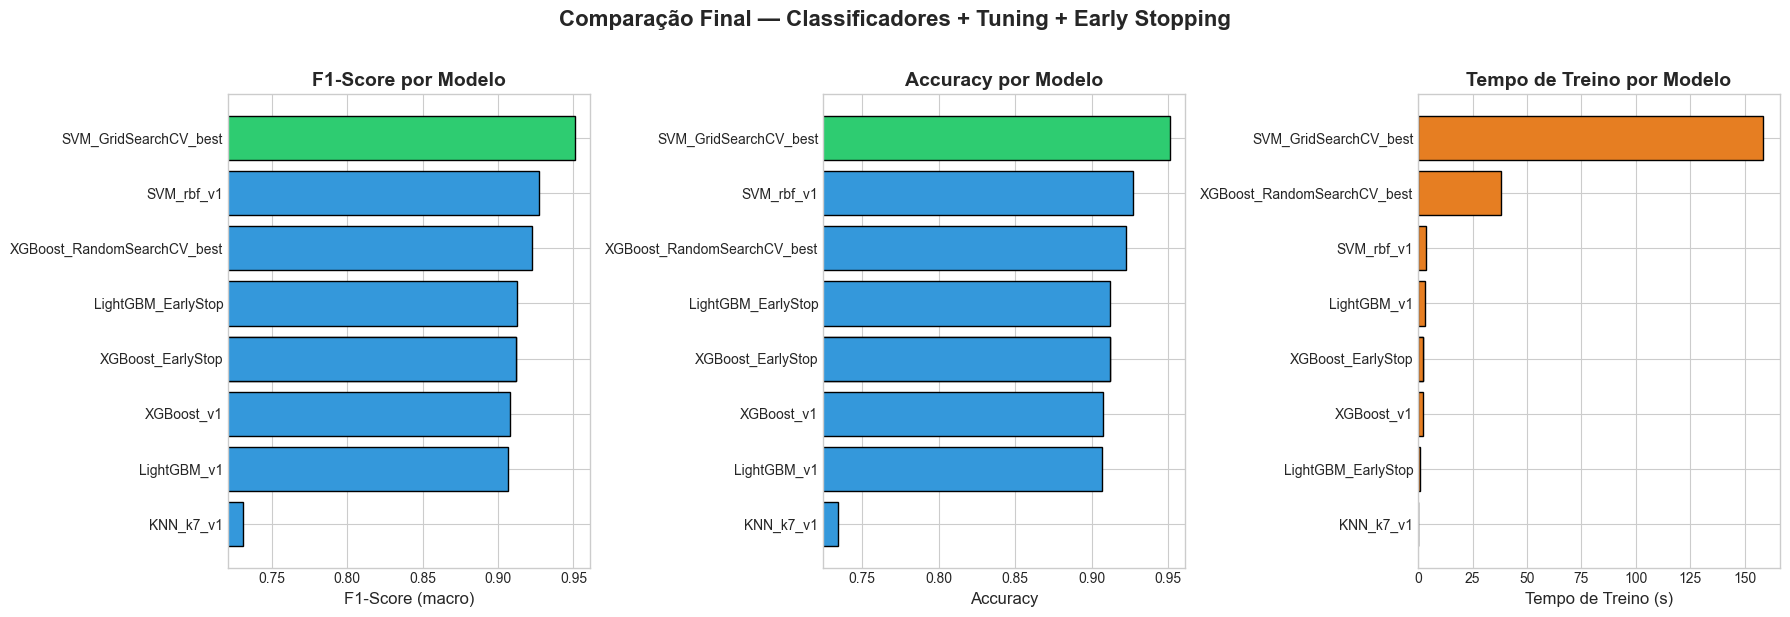


🏆 Melhor F1-Score:  SVM_GridSearchCV_best (0.9510)
⚡ Mais rápido:      KNN_k7_v1 (0.042s)

💡 Análise:
   Se precisar de MÁXIMA ACURÁCIA → use SVM_GridSearchCV_best
   Se precisar de VELOCIDADE → use KNN_k7_v1
   Se precisar de INTERPRETABILIDADE → considere SVM com kernel linear ou KNN


In [22]:
# ============================================================
# COMPARAÇÃO FINAL DE TODOS OS MODELOS
# ============================================================

df_final = pd.DataFrame(resultados_todos)[['modelo', 'accuracy', 'f1_macro', 'tempo_treino']]
df_final = df_final.sort_values('f1_macro', ascending=False).reset_index(drop=True)
df_final.index = df_final.index + 1  # Rankings começam em 1

print("=" * 80)
print("📊 RANKING FINAL — TODOS OS MODELOS DA AULA 2")
print("=" * 80)
print(df_final.to_string())
print("=" * 80)

# --- Gráfico comparativo ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico 1: F1-Score
df_plot = df_final.sort_values('f1_macro', ascending=True)
colors_f1 = ['#2ecc71' if x == df_plot['f1_macro'].max() else '#3498db'
             for x in df_plot['f1_macro']]
axes[0].barh(df_plot['modelo'], df_plot['f1_macro'], color=colors_f1, edgecolor='black')
axes[0].set_xlabel('F1-Score (macro)', fontsize=12)
axes[0].set_title('F1-Score por Modelo', fontsize=14, fontweight='bold')
axes[0].set_xlim(df_plot['f1_macro'].min() - 0.01, df_plot['f1_macro'].max() + 0.01)

# Gráfico 2: Accuracy
df_plot2 = df_final.sort_values('accuracy', ascending=True)
colors_acc = ['#2ecc71' if x == df_plot2['accuracy'].max() else '#3498db'
              for x in df_plot2['accuracy']]
axes[1].barh(df_plot2['modelo'], df_plot2['accuracy'], color=colors_acc, edgecolor='black')
axes[1].set_xlabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy por Modelo', fontsize=14, fontweight='bold')
axes[1].set_xlim(df_plot2['accuracy'].min() - 0.01, df_plot2['accuracy'].max() + 0.01)

# Gráfico 3: Tempo de treino
df_plot3 = df_final.sort_values('tempo_treino', ascending=True)
colors_tempo = ['#2ecc71' if x == df_plot3['tempo_treino'].min() else '#e67e22'
                for x in df_plot3['tempo_treino']]
axes[2].barh(df_plot3['modelo'], df_plot3['tempo_treino'], color=colors_tempo, edgecolor='black')
axes[2].set_xlabel('Tempo de Treino (s)', fontsize=12)
axes[2].set_title('Tempo de Treino por Modelo', fontsize=14, fontweight='bold')

plt.suptitle('Comparação Final — Classificadores + Tuning + Early Stopping',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparacao_final_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Análise automática ---
melhor_f1 = df_final.iloc[0]
mais_rapido = df_final.loc[df_final['tempo_treino'].idxmin()]

print(f"\n🏆 Melhor F1-Score:  {melhor_f1['modelo']} ({melhor_f1['f1_macro']:.4f})")
print(f"⚡ Mais rápido:      {mais_rapido['modelo']} ({mais_rapido['tempo_treino']:.3f}s)")
print(f"\n💡 Análise:")
print(f"   Se precisar de MÁXIMA ACURÁCIA → use {melhor_f1['modelo']}")
print(f"   Se precisar de VELOCIDADE → use {mais_rapido['modelo']}")
print(f"   Se precisar de INTERPRETABILIDADE → considere SVM com kernel linear ou KNN")

## 🔟 Exportação do Melhor Modelo

Vamos exportar o **melhor modelo** desta aula (por F1-Score) seguindo a mesma convenção de nomenclatura da Aula 1:

```
modelos/aula02/
├── <algoritmo>_qualidade_textil_v1.joblib   ← Modelo treinado
├── scaler_qualidade_textil_v1.joblib        ← StandardScaler
└── features_qualidade_textil_v1.joblib      ← Lista de features
```

In [23]:
# ============================================================
# EXPORTAÇÃO DO MELHOR MODELO
# ============================================================

# Caminho padrão para modelos
MODELOS_DIR = os.path.join("..", "modelos", "aula02")
os.makedirs(MODELOS_DIR, exist_ok=True)

# Identifica o melhor modelo
df_ranking = pd.DataFrame(resultados_todos)[['modelo', 'f1_macro']].sort_values('f1_macro', ascending=False)
melhor_nome = df_ranking.iloc[0]['modelo']
print(f"🏆 Melhor modelo: {melhor_nome}")

# Mapeia o nome para o objeto do modelo
mapa_modelos = {
    "SVM_rbf_v1": modelo_svm,
    "KNN_k7_v1": modelo_knn,
    "XGBoost_v1": modelo_xgb,
    "LightGBM_v1": modelo_lgbm,
    "SVM_GridSearchCV_best": grid_search_svm.best_estimator_,
    "XGBoost_RandomSearchCV_best": random_search_xgb.best_estimator_,
    "XGBoost_EarlyStop": modelo_xgb_es,
    "LightGBM_EarlyStop": modelo_lgbm_es,
}

melhor_modelo_obj = mapa_modelos.get(melhor_nome)

# Define prefixo do algoritmo para o nome do arquivo
prefixos = {
    "SVM": "svm", "KNN": "knn", "XGBoost": "xgb", "LightGBM": "lgbm"
}
prefixo = "modelo"
for chave, valor in prefixos.items():
    if chave in melhor_nome:
        prefixo = valor
        break

# --- Salva o modelo ---
modelo_path = os.path.join(MODELOS_DIR, f"{prefixo}_qualidade_textil_v1.joblib")
joblib.dump(melhor_modelo_obj, modelo_path)

# --- Salva o scaler ---
scaler_path = os.path.join(MODELOS_DIR, "scaler_qualidade_textil_v1.joblib")
joblib.dump(scaler, scaler_path)

# --- Salva a lista de features ---
features_path_out = os.path.join(MODELOS_DIR, "features_qualidade_textil_v1.joblib")
joblib.dump(feature_names, features_path_out)

# Exporta também TODOS por modelo para referência futura
for nome, obj in mapa_modelos.items():
    p = "modelo"
    for chave, valor in prefixos.items():
        if chave in nome:
            p = valor
            break
    sufixo = nome.lower().replace(" ", "_")
    path_extra = os.path.join(MODELOS_DIR, f"{p}_{sufixo}_qualidade_textil_v1.joblib")
    joblib.dump(obj, path_extra)

print(f"\n💾 Artefatos exportados em {MODELOS_DIR}:")
for f in sorted(os.listdir(MODELOS_DIR)):
    size_kb = os.path.getsize(os.path.join(MODELOS_DIR, f)) / 1024
    print(f"   📦 {f}: {size_kb:.1f} KB")

🏆 Melhor modelo: SVM_GridSearchCV_best

💾 Artefatos exportados em ..\modelos\aula02:
   📦 features_qualidade_textil_v1.joblib: 0.3 KB
   📦 knn_knn_k7_v1_qualidade_textil_v1.joblib: 5273.1 KB
   📦 lgbm_lightgbm_earlystop_qualidade_textil_v1.joblib: 4957.8 KB
   📦 lgbm_lightgbm_v1_qualidade_textil_v1.joblib: 1015.4 KB
   📦 scaler_qualidade_textil_v1.joblib: 1.4 KB
   📦 svm_qualidade_textil_v1.joblib: 756.6 KB
   📦 svm_svm_gridsearchcv_best_qualidade_textil_v1.joblib: 756.6 KB
   📦 svm_svm_rbf_v1_qualidade_textil_v1.joblib: 1089.1 KB
   📦 xgb_xgboost_earlystop_qualidade_textil_v1.joblib: 6213.5 KB
   📦 xgb_xgboost_randomsearchcv_best_qualidade_textil_v1.joblib: 978.2 KB
   📦 xgb_xgboost_v1_qualidade_textil_v1.joblib: 1354.5 KB


In [25]:
# ============================================================
# TESTE: CARREGAR E VERIFICAR O MODELO EXPORTADO
# ============================================================

print("🔄 Testando carregamento do modelo exportado...\n")

# Carrega o modelo e o scaler
modelo_carregado = joblib.load(modelo_path)
scaler_carregado = joblib.load(scaler_path)
features_carregadas = joblib.load(features_path_out)

# Pega uma amostra do conjunto de teste
amostra = X_test.iloc[[0]]
valor_real = y_test.iloc[0]

# Aplica scaler e faz predição
amostra_scaled = scaler_carregado.transform(amostra)
predicao = modelo_carregado.predict(amostra_scaled)[0]

# Converte de volta para nome da classe
try:
    classe_predita = le_target.inverse_transform([int(predicao)])[0]
    classe_real = le_target.inverse_transform([int(valor_real)])[0]
except:
    mapa = {0: 'High', 1: 'Low', 2: 'Medium'}
    classe_predita = mapa.get(int(predicao), str(predicao))
    classe_real = mapa.get(int(valor_real), str(valor_real))

print(f"📥 Dados de entrada: {amostra.values[0][:5]}... ({len(features_carregadas)} features)")
print(f"\n🎯 Resultado:")
print(f"   Predição: {classe_predita}")
print(f"   Real:     {classe_real}")
print(f"   Correto?  {'✅ SIM!' if int(predicao) == int(valor_real) else '❌ NÃO'}")
print(f"\n✅ Modelo exportado e validado com sucesso!")

🔄 Testando carregamento do modelo exportado...

📥 Dados de entrada: [216.         311.          67.77268261   4.85722994   1.        ]... (15 features)

🎯 Resultado:
   Predição: Low
   Real:     Low
   Correto?  ✅ SIM!

✅ Modelo exportado e validado com sucesso!


In [26]:
# ============================================================
# REGISTRAR ARTEFATOS FINAIS NO MLFLOW
# ============================================================
# Salva os gráficos de comparação como artefatos do melhor run.

with mlflow.start_run(run_name="Aula02_Resumo_Final"):
    # Registra métricas do melhor modelo
    melhor_row = df_final.iloc[0]
    mlflow.log_param("melhor_modelo", melhor_row['modelo'])
    mlflow.log_metric("melhor_f1_macro", melhor_row['f1_macro'])
    mlflow.log_metric("melhor_accuracy", melhor_row['accuracy'])
    mlflow.log_param("total_modelos_treinados", len(resultados_todos))

    # Registra gráficos
    for arquivo in ['pair_plot_features.png', 'vif_features.png',
                     'correlacao_com_target.png', 'comparacao_final_modelos.png',
                     'xgb_early_stopping.png', 'lgbm_early_stopping.png']:
        if os.path.exists(arquivo):
            mlflow.log_artifact(arquivo, "graficos")

    # Salva tabela de resultados como CSV
    df_final.to_csv('resultados_aula02.csv', index=False)
    mlflow.log_artifact('resultados_aula02.csv', "resultados")

    print("✅ Artefatos finais registrados no MLflow!")
    print(f"\n🔗 Para visualizar todos os runs:")
    print(f"   mlflow ui --backend-store-uri sqlite:///mlflow.db")
    print(f"   Acesse: http://localhost:5000")

✅ Artefatos finais registrados no MLflow!

🔗 Para visualizar todos os runs:
   mlflow ui --backend-store-uri sqlite:///mlflow.db
   Acesse: http://localhost:5000


---

## 📝 Atividade Complementar (Tempo estimado: 1h)

### Objetivo

Praticar **hyperparameter tuning** e **comparação de modelos** modificando os classificadores já treinados.

### Tarefas:

**Tarefa 1 — Tuning do KNN com GridSearchCV**
- Crie um GridSearchCV para o KNN testando diferentes valores de `n_neighbors`: [3, 5, 7, 11, 15, 21]
- Teste também duas métricas de distância: `euclidean` e `manhattan`
- Registre no MLflow como `"KNN_GridSearchCV_best"`
- O melhor K encontrado melhorou em relação ao KNN_k7_v1?

**Tarefa 2 — Análise de Sensibilidade do K no KNN**
- Treine o KNN variando K de 1 a 25 (apenas ímpares)
- Para cada K, calcule o F1-Score via `cross_val_score` (5-fold)
- Plote um gráfico mostrando F1-Score vs K
- Em qual K o modelo atinge o pico? Após o pico, o que acontece com o desempenho?

> 💡 **Dicas:** Use as células abaixo como guia. Substitua os trechos com `# SEU CÓDIGO AQUI`.

In [27]:
# ============================================================
# TAREFA 1 — GridSearchCV no KNN
# ============================================================
# Dica: siga a mesma estrutura da seção 7.1 (GridSearchCV com SVM)

# Defina o grid de hiperparâmetros

params_knn = {
    "n_neighbors": 15,       # 15 vizinhos (número ímpar evita empate)
    "metric": "manhattan",   # Distância de Minkowski (padrão = Euclidiana com p=2)
    "p": 2,                  # p=2 → distância Euclidiana
    "n_jobs": -1             # Usa todos os cores (paraleliza o cálculo de distâncias)
}

# Conte quantas combinações serão testadas

# Conta total de combinações
n_combinacoes = 1
for v in params_knn.values():
    n_combinacoes *= len(v)
print(f"🔍 GridSearchCV — KNN")
print(f"   Combinações a testar: {n_combinacoes}")
print(f"   Com 7-fold CV: {n_combinacoes * 7} modelos serão treinados")
print(f"   Grid: {params_knn}\n")

# SEU CÓDIGO AQUI — Crie o GridSearchCV

inicio = time.time()
grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=params_knn,
    cv=7,                  # 7-fold cross-validation
    scoring='f1_macro',    # Métrica para comparação
    n_jobs=-1,             # Paraleliza nos cores do CPU
    verbose=0,             # Sem output verbose
    return_train_score=True  # Também salva score do treino
)

# SEU CÓDIGO AQUI — Fit no treino escalado
grid_search_knn.fit(X_train_scaled, y_train)
tempo_grid = time.time() - inicio

# Melhores parâmetros
# Mostra os melhores parâmetros encontrados
print(f"✅ GridSearchCV concluído em {tempo_grid:.1f}s")
print(f"\n🏆 Melhores hiperparâmetros encontrados:")
for param, valor in grid_search_knn.best_params_.items():
    print(f"   {param}: {valor}")
print(f"\n📊 Melhor F1-Score (CV): {grid_search_knn.best_score_:.4f}")

# SEU CÓDIGO AQUI — Avalie no conjunto de teste
# --- Registra no MLflow ---
resultado_grid_knn = treinar_e_avaliar(
    modelo=grid_search_knn.best_estimator_,
    nome_run="KNN_GridSearchCV_V1",
    params_dict={**grid_search_knn.best_params_, "tuning": "GridSearchCV", "cv_folds": 7},
    X_tr=X_train_scaled,
    y_tr=y_train,
    X_te=X_test_scaled,
    y_te=y_test,
    nomes_classes=nomes_classes,
    tempo_treino=tempo_grid
)

# Compare com o KNN original (K=7)


TypeError: object of type 'int' has no len()

🔍 Testando KNN com K = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]...

   K= 1 → F1 = 0.6526 (±0.0026)
   K= 3 → F1 = 0.6772 (±0.0053)
   K= 5 → F1 = 0.6952 (±0.0014)
   K= 7 → F1 = 0.7258 (±0.0038)
   K= 9 → F1 = 0.7433 (±0.0033)
   K=11 → F1 = 0.7508 (±0.0056)
   K=13 → F1 = 0.7624 (±0.0046)
   K=15 → F1 = 0.7707 (±0.0080)
   K=17 → F1 = 0.7717 (±0.0068)
   K=19 → F1 = 0.7802 (±0.0054)
   K=21 → F1 = 0.7834 (±0.0042)
   K=23 → F1 = 0.7869 (±0.0045)
   K=25 → F1 = 0.7924 (±0.0020)


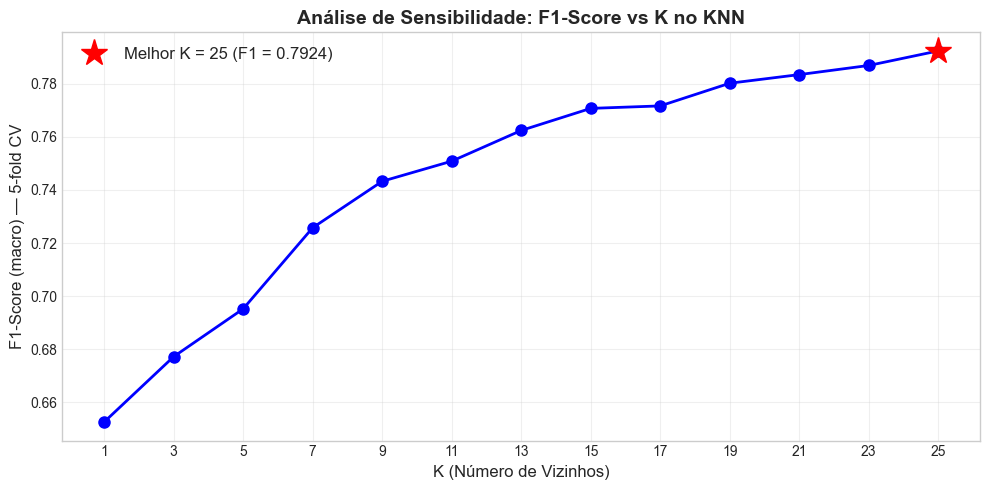


🏆 Melhor K = 25 com F1 = 0.7924
💡 Observe: após K ~ 25, o desempenho começa a cair.
   Isso acontece porque com K muito grande, o modelo fica 'generalista demais'
   e perde a capacidade de capturar padrões locais nos dados.


In [ ]:
# ============================================================
# TAREFA 2 — Análise de Sensibilidade do K
# ============================================================
# Plote F1-Score vs K para K = 1, 3, 5, ..., 25

# Valores de K a testar (apenas ímpares)

# SEU CÓDIGO AQUI — Plote o gráfico

# Destaca o melhor K

### ✍️ Reflexão Final

**Responda abaixo (clique duas vezes nesta célula para editar):**

1. **Qual classificador teve o melhor F1-Score nesta aula?**
   - Resposta: *(escreva aqui)*

2. **O Hyperparameter Tuning (GridSearchCV/RandomizedSearchCV) melhorou os resultados em relação aos modelos base?**
   - Resposta: *(escreva aqui)*

3. **O Early Stopping economizou quantos rounds no XGBoost? E no LightGBM?**
   - Resposta: *(escreva aqui)*

4. **Na indústria têxtil, se você precisasse de um modelo para classificação em tempo real na linha de produção, qual escolheria? Por quê?**
   - Resposta: *(escreva aqui)*

---

### 🎉 Parabéns!

Você completou a **Aula 2** e agora é capaz de:
- ✅ Analisar relações multivariadas entre features (pair plots, VIF)
- ✅ Treinar e comparar múltiplos classificadores (SVM, KNN, XGBoost, LightGBM)
- ✅ Usar GridSearchCV e RandomizedSearchCV para otimizar hiperparâmetros
- ✅ Aplicar Early Stopping para evitar overfitting
- ✅ Comparar modelos de forma estruturada e tomar decisões baseadas em dados

**Na próxima aula (Aula 3)**, vamos mudar o tipo de problema: em vez de classificação, faremos **regressão** para prever métricas contínuas de produção têxtil (consumo energético, produção esperada). 🚀